# Analyse Exploratoire du Dataset Yelp
Dans ce notebook, on va analyser la repartition des notes, la longueur des avis et les mots qui reviennent le plus.

### 1. Imports et config

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import json
import os

# on ajoute le dossier parent pour pouvoir importer src
sys.path.append(os.path.abspath('..'))

from src.data_loader import load_yelp_sample

# config pour que les graphs soient lisibles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Chargement des donnees

In [4]:
# chemin vers les fichiers
business_path = os.path.join("..", "data", "raw", "business.json")
review_path = os.path.join("..", "data", "raw", "review.json")

# 1. on charge tout le fichier business car il est pas trop lourd
data_business = []
if os.path.exists(business_path):
    with open(business_path, 'r', encoding='utf-8') as f:
        for line in f:
            data_business.append(json.loads(line))
    df_business = pd.DataFrame(data_business)
    print(f"Business charges : {df_business.shape}")
else:
    print("Fichier business.json introuvable")

# 2. on charge un echantillon des reviews (100k) sinon ca plante
df_reviews = load_yelp_sample(review_path, n_rows=100000)
if df_reviews is not None:
    print(f"Avis charges : {df_reviews.shape}")

Business charges : (150346, 14)
Chargement de 100000 lignes depuis ..\data\raw\review.json...
Avis charges : (100000, 9)


### 3. Repartition des notes
On regarde si les gens mettent souvent 5 etoiles ou 1 etoile.

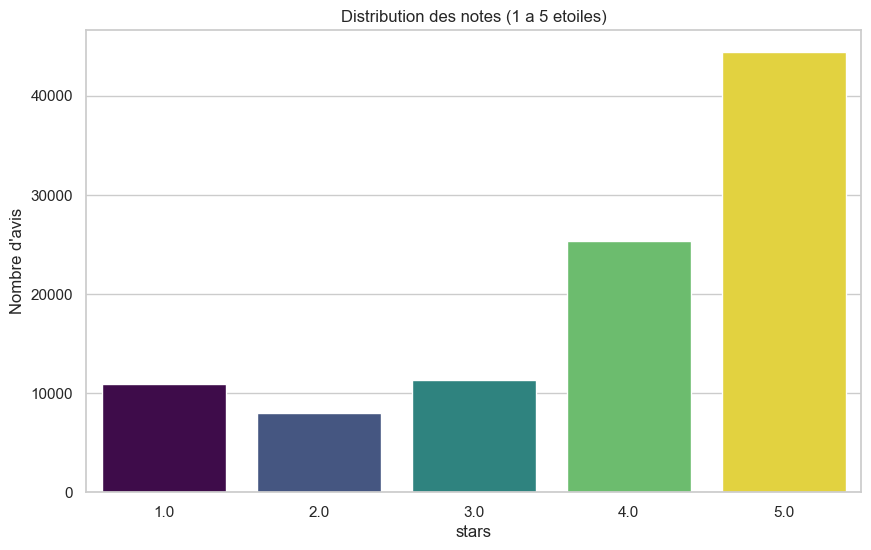

stars
1.0    10.921
2.0     7.988
3.0    11.362
4.0    25.337
5.0    44.392
Name: proportion, dtype: float64


In [9]:
if df_reviews is not None:
    # histogramme des notes
    sns.countplot(x='stars', data=df_reviews, hue='stars', palette='viridis', legend=False)
    plt.title('Distribution des notes (1 a 5 etoiles)')
    plt.ylabel("Nombre d'avis")
    plt.show()

    # affichage des pourcentages
    print(df_reviews['stars'].value_counts(normalize=True).sort_index() * 100)

### 4. Lien entre longueur du texte et la note
Est-ce que les avis negatifs sont plus longs ?

C:\Users\bapti\AppData\Local\Temp\ipykernel_25268\3501873634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stars', y='text_length', data=df_reviews, palette='coolwarm', showfliers=False)


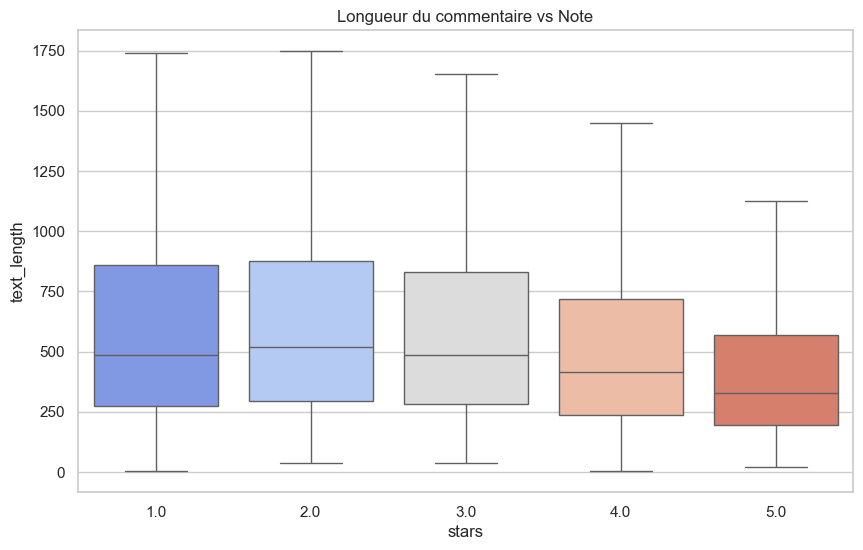

In [6]:
if df_reviews is not None:
    # on calcule la taille de chaque avis
    df_reviews['text_length'] = df_reviews['text'].apply(len)

    # boxplot pour voir la moyenne par note
    sns.boxplot(x='stars', y='text_length', data=df_reviews, palette='coolwarm', showfliers=False)
    plt.title('Longueur du commentaire vs Note')
    plt.show()

### 5. Analyse specifique aux Restaurants
On filtre pour ne garder que les commerces de type Restaurant.

In [7]:
# on cherche les business qui ont 'Restaurant' dans leurs categories
restaurants = df_business[df_business['categories'].str.contains('Restaurant', case=False, na=False)]

# on fait la jointure avec les reviews
df_rest = df_reviews.merge(restaurants[['business_id', 'name', 'categories']], on='business_id', how='inner')

print(f"Restaurants trouves : {len(restaurants)}")
print(f"Avis sur les restaurants : {len(df_rest)}")
print(f"Note moyenne des restos : {df_rest['stars'].mean():.2f}/5")

Restaurants trouves : 52286
Avis sur les restaurants : 72125
Note moyenne des restos : 3.81/5


### 6. Les mots les plus frequents
On regarde quels mots reviennent le plus pour les avis 5 etoiles vs 1 etoile.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

# on recupere les mots vides (le, la, un...)
nltk.download('stopwords', quiet=True)
stop_words = list(stopwords.words('english'))

def show_top_words(texts, title):
    # on compte les mots en enlevant les stop words
    vec = CountVectorizer(stop_words=stop_words, max_features=20)
    bag_of_words = vec.fit_transform(texts)
    sum_words = bag_of_words.sum(axis=0)
    
    # on trie par frequence
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    # on affiche le top 10
    top_df = pd.DataFrame(words_freq[:10], columns=['Mot', 'Frequence'])
    print(f"\n--- {title} ---")
    print(top_df)

if df_reviews is not None:
    # top mots avis positifs
    pos_text = df_reviews[df_reviews['stars'] == 5]['text'].head(2000)
    show_top_words(pos_text, "TOP MOTS : AVIS POSITIFS (5/5)")
    
    # top mots avis negatifs
    neg_text = df_reviews[df_reviews['stars'] == 1]['text'].head(2000)
    show_top_words(neg_text, "TOP MOTS : AVIS NEGATIFS (1/5)")


--- TOP MOTS : AVIS POSITIFS (5/5) ---
       Mot  Frequence
0    great       1185
1    place        981
2     food        914
3     good        726
4     time        552
5  service        547
6     best        531
7       go        505
8     back        465
9      get        460

--- TOP MOTS : AVIS NEGATIFS (1/5) ---
       Mot  Frequence
0     food       1192
1    would        981
2      one        918
3    place        911
4  service        898
5     back        890
6      get        881
7     time        856
8     like        811
9       us        791
